# CNN — PyTorch Pipeline

## Model: Convolutional Neural Network (CNN)
- **Dataset**: CIFAR-100 — 50,000 train / 10,000 test, 32×32×3 color images
- **Task**: Classify 100 fine classes (20 superclasses), perfectly balanced
- **Framework showcase**: Architecture sweep (depth/width) + data augmentation impact + superclass confusion analysis

## Evaluation Strategy
- **Metrics**: Accuracy, Macro F1, per-class F1, superclass confusion matrix
- **Training curves**: Loss + accuracy (train/val) with early stopping
- **Hierarchical analysis**: Fine-class (100) and superclass (20) evaluation

## Pipeline
1. Load data + config
2. Baseline CNN (3 conv layers)
3. Training visualization
4. Architecture sweep (shallow/baseline/deep/wide)
5. Best model — full evaluation
6. Superclass confusion analysis
7. Data augmentation impact
8. Performance benchmarks
9. Save results

In [1]:
# Step 1: Setup

"""
Imports, config, load CIFAR-100, build fine→coarse mapping
Data augmentation via torchvision.transforms (train only)
Per-channel normalization from EDA: R=0.507, G=0.487, B=0.441
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as transforms
import sys
import os
sys.path.append('../..')

from utils.data_loader import load_processed_data
from utils.metrics import evaluate_classifier, macro_f1_score
from utils.visualization import (plot_training_history, plot_confusion_matrix_multiclass,
                                  plot_per_class_f1, plot_superclass_confusion)
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

# Config
RANDOM_STATE = 113
FRAMEWORK = "PyTorch"
MODEL_NAME = "CNN"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

BATCH_SIZE = 128
N_CLASSES = 100
N_SUPERCLASSES = 20
IMAGE_SHAPE = (3, 32, 32)  # Channel-first for PyTorch

# Per-channel stats from EDA (CIFAR-100 training set)
CHANNEL_MEANS = (0.5071, 0.4865, 0.4409)
CHANNEL_STDS = (0.2673, 0.2564, 0.2762)

# Load data via updated data_loader (auto-detects fine/coarse labels)
X_train, X_test, y_train, y_test, metadata = load_processed_data('cnn')

# Coarse labels from metadata (loaded by data_loader)
y_train_coarse = metadata['y_train_coarse']
y_test_coarse = metadata['y_test_coarse']

# Class names from metadata
FINE_NAMES = metadata['fine_class_names']
COARSE_NAMES = metadata['coarse_class_names']

# Build fine_to_coarse mapping array for plot_superclass_confusion
fine_to_coarse = np.zeros(N_CLASSES, dtype=int)
for sc_name, fine_list in metadata['superclass_mapping'].items():
    sc_idx = COARSE_NAMES.index(sc_name)
    for fc_name in fine_list:
        fc_idx = FINE_NAMES.index(fc_name)
        fine_to_coarse[fc_idx] = sc_idx

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(RANDOM_STATE)

# Convert to tensors — permute from (N,H,W,C) to (N,C,H,W) for PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

# Data augmentation (train only)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Normalize(mean=CHANNEL_MEANS, std=CHANNEL_STDS)
])

# Test transform (normalize only, no augmentation)
test_transform = transforms.Normalize(mean=CHANNEL_MEANS, std=CHANNEL_STDS)

# Apply test normalization now (static)
X_test_norm = test_transform(X_test_t)

# DataLoader for training (augmentation applied per batch in training loop)
train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

print("=" * 60)
print(f"[1/9] {FRAMEWORK} — {MODEL_NAME} Pipeline")
print("=" * 60)
print(f"Device: {device} ({torch.cuda.get_device_name() if torch.cuda.is_available() else 'CPU'})")
print(f"Train: {X_train_t.shape} | Test: {X_test_t.shape}")
print(f"Fine classes: {N_CLASSES} | Superclasses: {N_SUPERCLASSES}")
print(f"Batch size: {BATCH_SIZE} ({len(train_loader)} batches/epoch)")
print(f"Augmentation: HFlip, RandomCrop(4px pad), ColorJitter, Normalize")
print(f"Channel means: {CHANNEL_MEANS}")
print(f"Channel stds: {CHANNEL_STDS}")
print(f"GPU memory: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")

[1/9] PyTorch — CNN Pipeline
Device: cuda (NVIDIA GeForce RTX 4090)
Train: torch.Size([50000, 3, 32, 32]) | Test: torch.Size([10000, 3, 32, 32])
Fine classes: 100 | Superclasses: 20
Batch size: 128 (391 batches/epoch)
Augmentation: HFlip, RandomCrop(4px pad), ColorJitter, Normalize
Channel means: (0.5071, 0.4865, 0.4409)
Channel stds: (0.2673, 0.2564, 0.2762)
GPU memory: 822.5 MB


In [2]:
# Step 2: Baseline CNN

# 3 conv blocks: Conv2d -> BatchNorm -> ReLU -> MaxPool
# Followed by FC layers with dropout for regularization
# CrossEntropyLoss combines softmax + NLL (no softmax in model)

print("=" * 60)
print("[2/9] Baseline CNN — 3 Conv Layers")
print("=" * 60)

class CNN(nn.Module):
    """
    Configurable CNN for CIFAR-100 classification.

    Args:
        filters: List of filter counts per conv block, e.g. [32, 64, 128]
        fc_dim: Hidden dimension of FC layer before output
        n_classes: Number of output classes
        dropout: Dropout rate for FC layers
    """
    def __init__(self, filters, fc_dim=512, n_classes=100, dropout=0.5):
        super().__init__()
        # Build conv blocks: Conv → BN → ReLU → MaxPool(2)
        conv_layers = []
        in_ch = 3
        for f in filters:
            conv_layers.extend([
                nn.Conv2d(in_ch, f, kernel_size=3, padding=1),
                nn.BatchNorm2d(f),
                nn.ReLU(),
                nn.MaxPool2d(2)
            ])
            in_ch = f
        self.features = nn.Sequential(*conv_layers)

        # Spatial size after pooling: 32 / (2^n_layers)
        spatial = 32 // (2 ** len(filters))
        flat_size = filters[-1] * spatial * spatial

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(flat_size, fc_dim),
            nn.ReLU(),
            nn.Dropout(dropout * 0.6),
            nn.Linear(fc_dim, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.reshape(x.size(0), -1)
        return self.classifier(x)

def train_cnn(model, train_data, train_labels, transform, criterion,
              max_epochs=100, patience=15, lr=1e-3):
    """
    Train CNN with augmentation, validation split, early stopping.

    Returns train/val loss and accuracy histories.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Train/val split (90/10)
    n_val = int(len(train_data) * 0.1)
    perm = torch.randperm(len(train_data), device=device,
                           generator=torch.Generator(device=device).manual_seed(RANDOM_STATE))
    val_idx, tr_idx = perm[:n_val], perm[n_val:]

    X_val = test_transform(train_data[val_idx])  # Normalize only, no augmentation
    y_val = train_labels[val_idx]
    X_tr = train_data[tr_idx]
    y_tr = train_labels[tr_idx]

    tr_ds = TensorDataset(X_tr, y_tr)
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)

    best_val_loss = float('inf')
    wait = 0
    best_state = None
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(max_epochs):
        # Train
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0
        for batch_x, batch_y in tr_loader:
            # Apply augmentation per batch
            batch_x = transform(batch_x)
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch_y)
            correct += (logits.argmax(1) == batch_y).sum().item()
            total += len(batch_y)

        train_losses.append(epoch_loss / total)
        train_accs.append(correct / total)

        # Validate
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val).item()
            val_acc = (val_logits.argmax(1) == y_val).float().mean().item()
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            wait = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    best_epoch = len(train_losses) - patience

    return {
        'train_loss': train_losses,
        'val_loss': val_losses,
        'train_acc': train_accs,
        'val_acc': val_accs,
        'best_epoch': best_epoch,
        'epochs': len(train_losses)
    }

# Build baseline CNN
baseline_cnn = CNN(filters=[32, 64, 128], fc_dim=512, n_classes=N_CLASSES, dropout=0.5).to(device)
criterion = nn.CrossEntropyLoss()
n_params = sum(p.numel() for p in baseline_cnn.parameters())

print(f"Architecture: Conv(32)->Conv(64)->Conv(128)->FC(512)->FC(100)")
print(f"Parameters: {n_params:,}")

# Train
with track_performance(gpu=True) as perf:
    history = train_cnn(baseline_cnn, X_train_t, y_train_t, train_transform,
                        criterion, max_epochs=100, patience=15)
    torch.cuda.synchronize()

# Evaluate on test set
baseline_cnn.eval()
with torch.no_grad():
    test_logits = baseline_cnn(X_test_norm)
    test_preds = test_logits.argmax(1).cpu().numpy()
    test_proba = torch.softmax(test_logits, dim=1).cpu().numpy()

test_metrics = evaluate_classifier(y_test, test_preds, test_proba)

print(f"\nEpochs: {history['epochs']} (early stopped ~epoch {history['best_epoch']})")
print(f"Training time: {perf['time']:.2f}s")
print(f"GPU memory: {perf['gpu_memory']:.2f} MB")
print(f"\nTest Results:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

[2/9] Baseline CNN — 3 Conv Layers
Architecture: Conv(32)→Conv(64)→Conv(128)→FC(512)→FC(100)
Parameters: 1,194,084

Epochs: 100 (early stopped ~epoch 85)
Training time: 161.32s
GPU memory: 2703.70 MB

Test Results:
  accuracy: 0.5685
  macro_f1: 0.5628
  log_loss: 1.5848
  brier_score: 0.5589
  ece: 0.0243


[3/9] Training Visualization


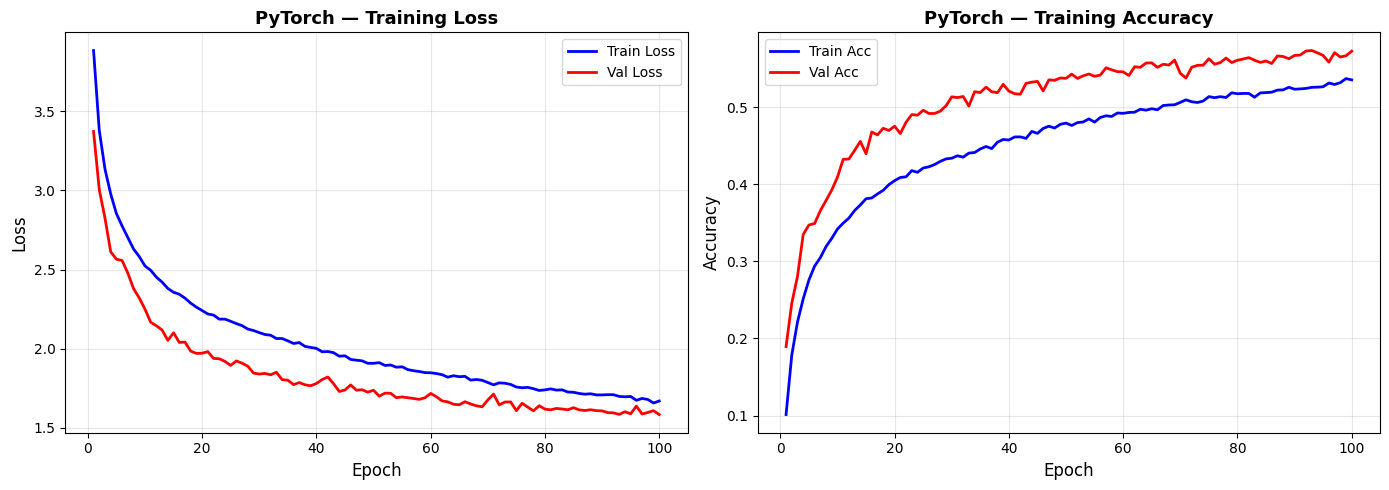


Best val accuracy: 0.5732 (epoch 85)
Final train accuracy: 0.5352
Overfitting gap: -0.0372


In [4]:
# Step 3: Training Visualization

"""
plot_training_history auto-detects train_acc/val_acc keys
and creates dual-panel figure (loss + accuracy)
"""

print("=" * 60)
print("[3/9] Training Visualization")
print("=" * 60)

plot_training_history(
    history=history,
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/training_history_baseline.png'
)

print(f"\nBest val accuracy: {max(history['val_acc']):.4f} (epoch {history['best_epoch']})")
print(f"Final train accuracy: {history['train_acc'][-1]:.4f}")
print(f"Overfitting gap: {history['train_acc'][-1] - history['val_acc'][-1]:.4f}")